In [1]:
# --- 03b_Modeling_RandomForest.ipynb ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, f1_score, roc_auc_score
import os



In [2]:
# Step 1: Loading the UNSCALED Data
# no need scaled data
train_data = pd.read_csv('../data/processed/train_unscaled.csv')
test_data = pd.read_csv('../data/processed/test_unscaled.csv')

X_train = train_data.drop(columns=['target'])
y_train = train_data['target']

X_test = test_data.drop(columns=['target'])
y_test = test_data['target']


In [3]:
# Step 2: Model Initialization and Training

# class_weight='balanced': Azınlık sınıfına veya yakalanması zor olan sınıfa ağırlık verir.
# n_estimators=100
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
print(y_pred)

[0 1 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 0 1 0 1 0 1 0 0 1
 1 0 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 0 1 0 0 1 1 1 0 1 0 0 1 0 0 1 0 0 0 0
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0
 0 1 1 1 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 0 0 1
 1 0 0 1 1 1 1 1 0 0 0 0 1 0 1 0 1 0 1 1 1 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 1
 0 0 0 0 0 1 0 1 1 0 0 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 1 1 0 1 1 0 1 0 0 0 0
 0 0 1 0 1 1 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 1 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0
 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 0 1 0 0
 1 1 0 1 0 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 1 1 1 1 1 0 0 1 0
 0 0 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 0 0 0 1 0 0 1 1 1 1
 0 1 1 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0
 1 0 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 1 1 1 1 0 0
 0 0 1 1 0 1 1 0 1 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0]


In [4]:
# # Step 4: Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n--- Step 4: Performance Metrics ---")
print(f"Accuracy : {accuracy:.4f}")
print(f"Recall   : {recall:.4f}  --> (Umarım LR'den çok daha iyidir!)")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")



--- Step 4: Performance Metrics ---
Accuracy : 0.7336
Recall   : 0.6338  --> (Umarım LR'den çok daha iyidir!)
F1-Score : 0.6750
ROC-AUC  : 0.8292


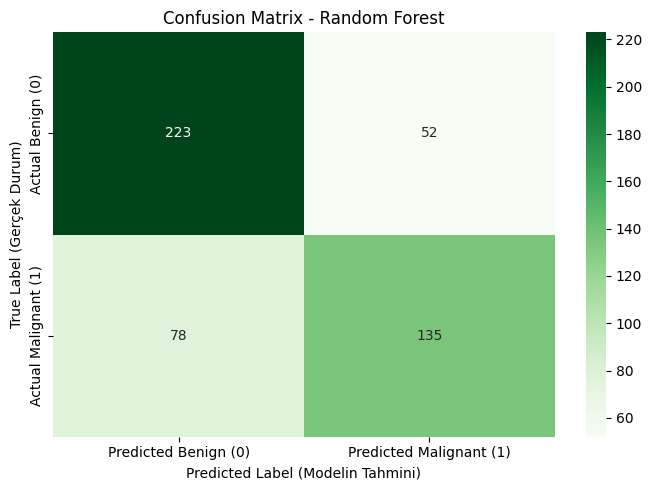

In [5]:
# ---------------------------------------------------------
# Step 5: Visualizing the Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
# Farkı belli etmek için yeşil (Greens) renk paleti kullanıyoruz
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predicted Benign (0)', 'Predicted Malignant (1)'],
            yticklabels=['Actual Benign (0)', 'Actual Malignant (1)'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label (Gerçek Durum)')
plt.xlabel('Predicted Label (Modelin Tahmini)')
plt.tight_layout()

# Grafiği reports/figures/ klasörüne otomatik kaydetme
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/02_RF_Confusion_Matrix.png', dpi=300)

plt.show()

--- Eski Recall (Threshold 0.50) : 0.6338 ---
--- YENİ Recall (Threshold 0.3) : 0.9108 ---


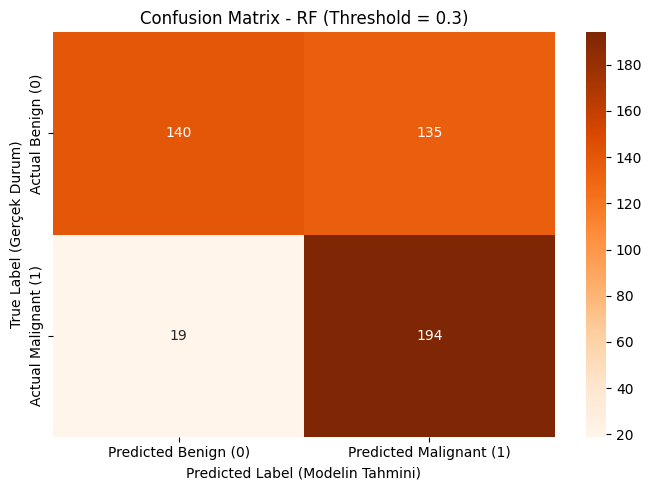

In [6]:
# ---------------------------------------------------------
# Step 6: Threshold Tuning (Medical AI Trick)
# ---------------------------------------------------------
# Kanser teşhisinde False Negative'leri azaltmak için eşik değerini 0.50'den 0.30'a çekiyoruz.
custom_threshold = 0.30

# Olasılık skorlarına göre yeni tahminler oluştur (Eğer ihtimal %30'dan büyükse 1 yap)
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

# Yeni metrikleri hesapla
recall_custom = recall_score(y_test, y_pred_custom)
cm_custom = confusion_matrix(y_test, y_pred_custom)

print(f"--- Eski Recall (Threshold 0.50) : {recall:.4f} ---")
print(f"--- YENİ Recall (Threshold {custom_threshold}) : {recall_custom:.4f} ---")

# Yeni Matrisi Çizdir
plt.figure(figsize=(7, 5))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Predicted Benign (0)', 'Predicted Malignant (1)'],
            yticklabels=['Actual Benign (0)', 'Actual Malignant (1)'])
plt.title(f'Confusion Matrix - RF (Threshold = {custom_threshold})')
plt.ylabel('True Label (Gerçek Durum)')
plt.xlabel('Predicted Label (Modelin Tahmini)')
plt.tight_layout()
plt.show()